In [1]:
# ── Project path setup ──────────────────────────────────────────────────
import sys
from pathlib import Path

# Add project root so that `from src.xxx import ...` works
PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> CPWpython/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /mnt/d/VIT/SEM 5/RIT HACKATHON - CPW/CPWpython


In [2]:
# ── Core imports ─────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display, Markdown, HTML

# ── Backend module imports ───────────────────────────────────────────────
from src.constants import C0, MU0, EPS0, QUBIT_BAND_GHZ, AL_GAP_FREQ_GHZ
from src.materials  import (
    Substrate, Conductor,
    SILICON, SAPPHIRE, QUARTZ, ALUMINA, FR4,
    ROGERS_4350B, ROGERS_5880, GAAS,
    NIOBIUM_PEC_SHEET, ALUMINUM_PEC_SHEET, NIOBIUM_THIN_FILM,
    get_substrate, get_conductor, list_substrates, list_conductors,
)
from src.calculator import (
    cpw_z0_eps_eff, solve_s_for_target_z0, solve_w_for_target_z0,
    phase_velocity, guided_wavelength, quarter_wave_length, half_wave_length,
    resonator_length, resonant_frequency, design_cpw,
    CPWCrossSection, CPWDesign,
)
from src.geometry import (
    CPWResonatorParams, CPWLayout, CPWModel3D,
    build_layout, build_3d_model, build_design,
    meander_path, polyline_length,
)

print("✅ All backend modules loaded successfully.")

✅ All backend modules loaded successfully.


In [3]:
# ── Physical constants ───────────────────────────────────────────────────
display(Markdown("### Physical Constants"))
print(f"  Speed of light (c₀)     : {C0:,.0f} m/s")
print(f"  Vacuum permeability (μ₀) : {MU0:.6e} H/m")
print(f"  Vacuum permittivity (ε₀) : {EPS0:.6e} F/m")
print(f"  Qubit band               : {QUBIT_BAND_GHZ[0]}–{QUBIT_BAND_GHZ[1]} GHz")
print(f"  Al gap frequency         : {AL_GAP_FREQ_GHZ} GHz")

### Physical Constants

  Speed of light (c₀)     : 299,792,458 m/s
  Vacuum permeability (μ₀) : 1.256637e-06 H/m
  Vacuum permittivity (ε₀) : 8.854188e-12 F/m
  Qubit band               : 4.0–8.0 GHz
  Al gap frequency         : 82.0 GHz


In [4]:
# ── Material database overview ───────────────────────────────────────────
display(Markdown("### Available Substrates"))
print(f"{'Name':<20} {'εᵣ':>6} {'Thickness (μm)':>16} {'tan δ':>10}")
print("─" * 56)
for key in list_substrates():
    s = get_substrate(key)
    print(f"{s.name:<20} {s.eps_r:>6.1f} {s.thickness_m*1e6:>16.0f} {s.loss_tangent:>10.5f}")

print()
display(Markdown("### Available Conductors"))
print(f"{'Name':<35} {'PEC':>5} {'Thickness (nm)':>16} {'Tc (K)':>8}")
print("─" * 68)
for key in list_conductors():
    c = get_conductor(key)
    tc = f"{c.Tc_K:.1f}" if c.Tc_K else "N/A"
    print(f"{c.name:<35} {str(c.is_pec):>5} {c.thickness_m*1e9:>16.0f} {tc:>8}")

### Available Substrates

Name                     εᵣ   Thickness (μm)      tan δ
────────────────────────────────────────────────────────
Silicon                11.7              500    0.00000
Sapphire               10.0              430    0.00000
Quartz                  3.8              500    0.00010
Alumina                 9.9              635    0.00010
FR4                     4.4             1600    0.02000
Rogers 4350B            3.5              508    0.00370
Rogers 5880             2.2              254    0.00090
GaAs                   12.9              500    0.00200



### Available Conductors

Name                                  PEC   Thickness (nm)   Tc (K)
────────────────────────────────────────────────────────────────────
Niobium (lossless, PEC approx.)      True                0      9.2
Aluminum (lossless, PEC approx.)     True                0      1.2
Niobium thin film                    True              200      9.2


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
#  DESIGN PARAMETERS  — Edit these to customize your resonator
# ══════════════════════════════════════════════════════════════════════════

# RF targets
F0_GHZ          = 6.0                    # resonant frequency [GHz]
F0_HZ           = F0_GHZ * 1e9           # → Hz
TARGET_Z0_OHMS  = 50.0                   # characteristic impedance [Ω]

# Material selections
SUBSTRATE       = SILICON                # from materials library
CONDUCTOR       = NIOBIUM_PEC_SHEET      # from materials library

# Cross-section geometry
CENTER_WIDTH_UM = 10.0                   # center conductor width [μm]
CENTER_WIDTH_M  = CENTER_WIDTH_UM * 1e-6 # → meters

# Resonator mode
RESONATOR_MODE  = "quarter"              # "quarter" or "half"

# Meander layout
N_MEANDERS      = 3                      # number of U-turn pairs
MEANDER_PITCH   = 150e-6                 # vertical jog per turn [m]
COUPLING_LEN    = 300e-6                 # coupling section length [m]
COUPLING_GAP    = 20e-6                  # gap between feedline & resonator [m]

# Metal thickness (0.0 = ideal 2D PEC sheet, >0 for 3D extrusion)
METAL_THICKNESS = 10e-6                    # [m]  (try 200e-9 for Nb thin film)

print(f"✅ Design: f₀ = {F0_GHZ} GHz, Z₀ = {TARGET_Z0_OHMS} Ω")
print(f"   Substrate: {SUBSTRATE.name} (εᵣ = {SUBSTRATE.eps_r})")
print(f"   Conductor: {CONDUCTOR.name}")
print(f"   Center trace width: {CENTER_WIDTH_UM} μm")
print(f"   Mode: {RESONATOR_MODE}-wave")

✅ Design: f₀ = 6.0 GHz, Z₀ = 50.0 Ω
   Substrate: Silicon (εᵣ = 11.7)
   Conductor: Niobium (lossless, PEC approx.)
   Center trace width: 10.0 μm
   Mode: quarter-wave


In [6]:
# ── Step 4a: Solve cross-section for target impedance ────────────────────
cross_section = solve_s_for_target_z0(
    w_m=CENTER_WIDTH_M,
    target_z0_ohms=TARGET_Z0_OHMS,
    substrate=SUBSTRATE,
)

display(Markdown("### Cross-Section Solution"))
print(f"  Center conductor width (w) : {cross_section.width_m*1e6:.3f} μm")
print(f"  Gap width (s)              : {cross_section.gap_m*1e6:.3f} μm")
print(f"  Characteristic impedance   : {cross_section.z0_ohms:.4f} Ω")
print(f"  Effective permittivity     : {cross_section.eps_eff:.6f}")
print(f"  w/s ratio                  : {cross_section.width_m / cross_section.gap_m:.4f}")

### Cross-Section Solution

  Center conductor width (w) : 10.000 μm
  Gap width (s)              : 5.825 μm
  Characteristic impedance   : 50.0000 Ω
  Effective permittivity     : 6.350873
  w/s ratio                  : 1.7167


In [7]:
# ── Step 4b: Wave kinematics ─────────────────────────────────────────────
v_phase  = phase_velocity(cross_section.eps_eff)
lambda_g = guided_wavelength(F0_HZ, cross_section.eps_eff)
L_res    = resonator_length(F0_HZ, cross_section.eps_eff, mode=RESONATOR_MODE)

# Verify round-trip: length → frequency
f_check = resonant_frequency(L_res, cross_section.eps_eff, mode=RESONATOR_MODE)

display(Markdown("### Wave Kinematics"))
print(f"  Phase velocity             : {v_phase/1e6:.2f} × 10⁶ m/s  ({v_phase/C0:.6f} c₀)")
print(f"  Guided wavelength (λ_g)    : {lambda_g*1e3:.4f} mm")
print(f"  Resonator length (L)       : {L_res*1e3:.4f} mm  ({RESONATOR_MODE}-wave)")
print(f"  Frequency cross-check      : {f_check/1e9:.6f} GHz  (target: {F0_GHZ} GHz) ✅")

### Wave Kinematics

  Phase velocity             : 118.96 × 10⁶ m/s  (0.396811 c₀)
  Guided wavelength (λ_g)    : 19.8268 mm
  Resonator length (L)       : 4.9567 mm  (quarter-wave)
  Frequency cross-check      : 6.000000 GHz  (target: 6.0 GHz) ✅


In [8]:
# ── Step 4c: Full design API (wraps the above into one call) ─────────────
design = design_cpw(
    frequency_hz=F0_HZ,
    impedance_ohms=TARGET_Z0_OHMS,
    substrate=SUBSTRATE,
    width_m=CENTER_WIDTH_M,
    mode=RESONATOR_MODE,
)

display(Markdown("### Complete CPWDesign Object"))
print(f"  width_m             : {design.width_m*1e6:.3f} μm")
print(f"  gap_m               : {design.gap_m*1e6:.3f} μm")
print(f"  eps_eff             : {design.eps_eff:.6f}")
print(f"  z0_ohms             : {design.z0_ohms:.4f} Ω")
print(f"  resonator_length_m  : {design.resonator_length_m*1e3:.4f} mm")
print(f"  frequency_hz        : {design.frequency_hz/1e9:.4f} GHz")
print(f"  mode                : {design.mode}")

### Complete CPWDesign Object

  width_m             : 10.000 μm
  gap_m               : 5.825 μm
  eps_eff             : 6.350873
  z0_ohms             : 50.0000 Ω
  resonator_length_m  : 4.9567 mm
  frequency_hz        : 6.0000 GHz
  mode                : quarter


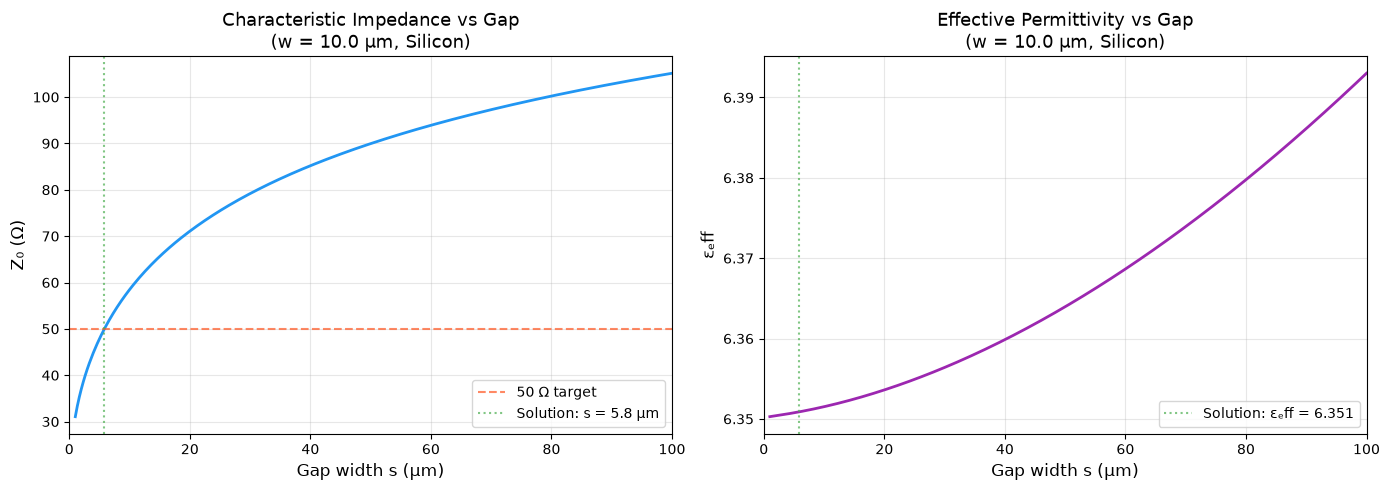

In [9]:
# ── Sweep: Z₀ and ε_eff vs gap width ────────────────────────────────────
gap_range_um = np.linspace(1, 100, 300)  # 1 μm to 100 μm
gap_range_m  = gap_range_um * 1e-6

z0_vals  = []
eps_vals = []
for s in gap_range_m:
    cs = cpw_z0_eps_eff(CENTER_WIDTH_M, s, SUBSTRATE)
    z0_vals.append(cs.z0_ohms)
    eps_vals.append(cs.eps_eff)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Z₀ vs gap
ax1.plot(gap_range_um, z0_vals, color='#2196F3', linewidth=2)
ax1.axhline(y=50, color='#FF5722', linestyle='--', alpha=0.7, label='50 Ω target')
ax1.axvline(x=cross_section.gap_m*1e6, color='#4CAF50', linestyle=':', alpha=0.7,
            label=f'Solution: s = {cross_section.gap_m*1e6:.1f} μm')
ax1.set_xlabel('Gap width s (μm)', fontsize=12)
ax1.set_ylabel('Z₀ (Ω)', fontsize=12)
ax1.set_title(f'Characteristic Impedance vs Gap\n(w = {CENTER_WIDTH_UM} μm, {SUBSTRATE.name})', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 100)

# ε_eff vs gap
ax2.plot(gap_range_um, eps_vals, color='#9C27B0', linewidth=2)
ax2.axvline(x=cross_section.gap_m*1e6, color='#4CAF50', linestyle=':', alpha=0.7,
            label=f'Solution: εₑff = {cross_section.eps_eff:.3f}')
ax2.set_xlabel('Gap width s (μm)', fontsize=12)
ax2.set_ylabel('εₑff', fontsize=12)
ax2.set_title(f'Effective Permittivity vs Gap\n(w = {CENTER_WIDTH_UM} μm, {SUBSTRATE.name})', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 100)

fig.tight_layout()
plt.show()

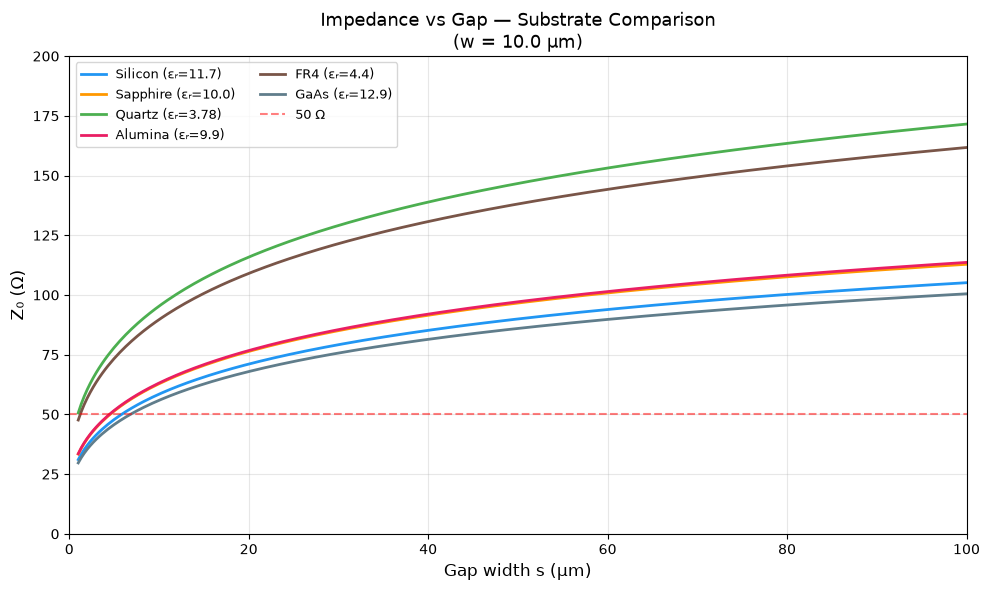

In [10]:
# ── Sweep: Z₀ across different substrates ────────────────────────────────
substrates_to_compare = [SILICON, SAPPHIRE, QUARTZ, ALUMINA, FR4, GAAS]
colors_list = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#795548', '#607D8B']

fig, ax = plt.subplots(figsize=(10, 6))

for sub, clr in zip(substrates_to_compare, colors_list):
    z0_sub = []
    for s in gap_range_m:
        try:
            cs = cpw_z0_eps_eff(CENTER_WIDTH_M, s, sub)
            z0_sub.append(cs.z0_ohms)
        except Exception:
            z0_sub.append(np.nan)
    ax.plot(gap_range_um, z0_sub, label=f"{sub.name} (εᵣ={sub.eps_r})",
            color=clr, linewidth=2)

ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50 Ω')
ax.set_xlabel('Gap width s (μm)', fontsize=12)
ax.set_ylabel('Z₀ (Ω)', fontsize=12)
ax.set_title(f'Impedance vs Gap — Substrate Comparison\n(w = {CENTER_WIDTH_UM} μm)', fontsize=13)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)
ax.set_ylim(0, 200)
fig.tight_layout()
plt.show()

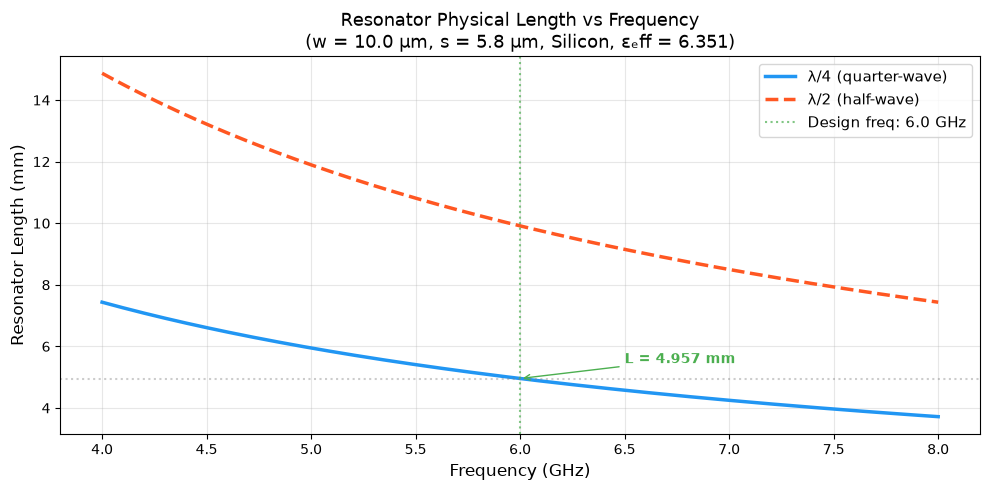

In [11]:
# ── Resonator length vs frequency sweep ──────────────────────────────────
freq_range_ghz = np.linspace(QUBIT_BAND_GHZ[0], QUBIT_BAND_GHZ[1], 200)
freq_range_hz  = freq_range_ghz * 1e9

lengths_qw = [quarter_wave_length(f, cross_section.eps_eff) * 1e3 for f in freq_range_hz]
lengths_hw = [half_wave_length(f, cross_section.eps_eff) * 1e3 for f in freq_range_hz]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(freq_range_ghz, lengths_qw, color='#2196F3', linewidth=2.5, label='λ/4 (quarter-wave)')
ax.plot(freq_range_ghz, lengths_hw, color='#FF5722', linewidth=2.5, label='λ/2 (half-wave)', linestyle='--')
ax.axvline(x=F0_GHZ, color='#4CAF50', linestyle=':', alpha=0.7, linewidth=1.5,
           label=f'Design freq: {F0_GHZ} GHz')
ax.axhline(y=L_res*1e3, color='gray', linestyle=':', alpha=0.4)

ax.set_xlabel('Frequency (GHz)', fontsize=12)
ax.set_ylabel('Resonator Length (mm)', fontsize=12)
ax.set_title(f'Resonator Physical Length vs Frequency\n'
             f'(w = {CENTER_WIDTH_UM} μm, s = {cross_section.gap_m*1e6:.1f} μm, '
             f'{SUBSTRATE.name}, εₑff = {cross_section.eps_eff:.3f})', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Annotate design point
ax.annotate(f'L = {L_res*1e3:.3f} mm',
            xy=(F0_GHZ, L_res*1e3), fontsize=10,
            xytext=(F0_GHZ + 0.5, L_res*1e3 + 0.5),
            arrowprops=dict(arrowstyle='->', color='#4CAF50'),
            color='#4CAF50', fontweight='bold')

fig.tight_layout()
plt.show()

In [12]:
# ── Build full parametric layout ─────────────────────────────────────────
params = CPWResonatorParams(
    f0_hz=F0_HZ,
    target_z0_ohms=TARGET_Z0_OHMS,
    substrate=SUBSTRATE,
    resonator_mode=RESONATOR_MODE,
    width_m=CENTER_WIDTH_M,
    n_meanders=N_MEANDERS,
    meander_pitch_m=MEANDER_PITCH,
    coupling_length_m=COUPLING_LEN,
    coupling_gap_m=COUPLING_GAP,
    metal_thickness_m=METAL_THICKNESS,
)

layout = build_layout(params)

display(Markdown("### Layout Metadata"))

m = layout.metadata

print(f"Bounding box (mm)")
print(f"  x = [{m.bounding_box[0]*1e3:.3f}, {m.bounding_box[2]*1e3:.3f}]")
print(f"  y = [{m.bounding_box[1]*1e3:.3f}, {m.bounding_box[3]*1e3:.3f}]")
print()

print(f"Chip size              : {(m.bounding_box[2]-m.bounding_box[0])*1e3:.3f} × {(m.bounding_box[3]-m.bounding_box[1])*1e3:.3f} mm")
print(f"Metal area             : {m.metal_area_sq_m*1e6:.4f} mm²")
print(f"Ground area            : {m.ground_area_sq_m*1e6:.4f} mm²")
print(f"Resonator length       : {m.resonator_length_actual_m*1e3:.4f} mm")
print(f"Feedline length        : {m.feedline_length_m*1e3:.4f} mm")

### Layout Metadata

Bounding box (mm)
  x = [-0.300, 4.657]
  y = [-0.310, 0.486]

Chip size              : 4.957 × 0.796 mm
Metal area             : 0.0640 mm²
Ground area            : 3.8072 mm²
Resonator length       : 4.9567 mm
Feedline length        : 1.3500 mm


In [13]:
# ── Port information ─────────────────────────────────────────────────────
display(Markdown("### Microwave Ports"))
for i, port in enumerate([layout.port1, layout.port2], 1):
    print(f"  Port {i}:")
    print(f"    Position   : ({port.position[0]*1e3:.3f}, {port.position[1]*1e3:.3f}) mm")
    print(f"    Direction  : {port.direction}")
    print(f"    Width      : {port.width_m*1e6:.1f} μm")
    print(f"    Impedance  : {port.impedance_ohms:.1f} Ω")

### Microwave Ports

  Port 1:
    Position   : (0.000, 0.000) mm
    Direction  : (-1.0, 0.0)
    Width      : 10.0 μm
    Impedance  : 50.0 Ω
  Port 2:
    Position   : (1.350, 0.000) mm
    Direction  : (1.0, 0.0)
    Width      : 10.0 μm
    Impedance  : 50.0 Ω


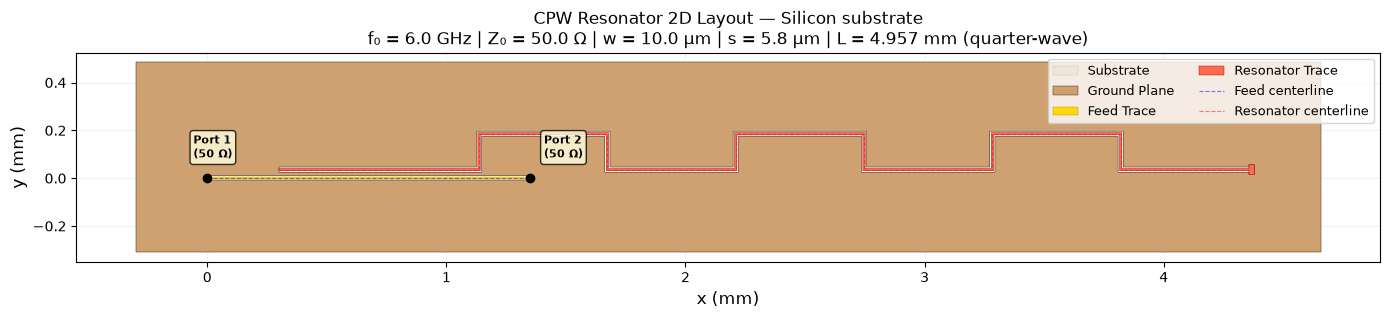

In [14]:
# ── 2D Layout Plot ───────────────────────────────────────────────────────
from shapely.geometry import MultiPolygon

def plot_layout(layout, figsize=(14, 8)):
    """Publication-quality 2D layout plot."""
    fig, ax = plt.subplots(figsize=figsize)
    
    def draw_poly(poly, color, label=None, alpha=1.0, edgecolor='black', lw=0.3):
        if poly is None or poly.is_empty:
            return
        geoms = poly.geoms if isinstance(poly, MultiPolygon) else [poly]
        first = True
        for g in geoms:
            xs = [x * 1e3 for x in g.exterior.xy[0]]
            ys = [y * 1e3 for y in g.exterior.xy[1]]
            ax.fill(xs, ys, color=color, alpha=alpha,
                    label=label if first else None,
                    edgecolor=edgecolor, linewidth=lw)
            for hole in g.interiors:
                hx = [x * 1e3 for x in hole.xy[0]]
                hy = [y * 1e3 for y in hole.xy[1]]
                ax.fill(hx, hy, color='white', edgecolor=edgecolor, linewidth=lw)
            first = False
    
    # Draw layers in order
    draw_poly(layout.substrate_footprint, '#E8E0D0', 'Substrate', alpha=0.4, edgecolor='#888')
    draw_poly(layout.ground_plane, '#C9935A', 'Ground Plane', alpha=0.85)
    draw_poly(layout.feed_trace, '#FFD700', 'Feed Trace', alpha=0.95, edgecolor='#B8860B')
    draw_poly(layout.resonator_trace, '#FF6347', 'Resonator Trace', alpha=0.95, edgecolor='#8B0000')
    
    # Draw centerlines
    feed_xs = [p[0]*1e3 for p in layout.feed_path]
    feed_ys = [p[1]*1e3 for p in layout.feed_path]
    ax.plot(feed_xs, feed_ys, 'b--', linewidth=0.8, alpha=0.5, label='Feed centerline')
    
    res_xs = [p[0]*1e3 for p in layout.resonator_path]
    res_ys = [p[1]*1e3 for p in layout.resonator_path]
    ax.plot(res_xs, res_ys, 'r--', linewidth=0.8, alpha=0.5, label='Resonator centerline')
    
    # Mark ports
    for i, port in enumerate([layout.port1, layout.port2], 1):
        ax.plot(port.position[0]*1e3, port.position[1]*1e3, 'ko', markersize=6)
        ax.annotate(f'Port {i}\n({port.impedance_ohms:.0f} Ω)',
                    xy=(port.position[0]*1e3, port.position[1]*1e3),
                    fontsize=8, fontweight='bold',
                    xytext=(10*port.direction[0], 15),
                    textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
    
    ax.set_aspect('equal')
    ax.set_xlabel('x (mm)', fontsize=12)
    ax.set_ylabel('y (mm)', fontsize=12)
    ax.set_title(
        f'CPW Resonator 2D Layout — {SUBSTRATE.name} substrate\n'
        f'f₀ = {F0_GHZ} GHz | Z₀ = {TARGET_Z0_OHMS} Ω | '
        f'w = {CENTER_WIDTH_UM} μm | s = {cross_section.gap_m*1e6:.1f} μm | '
        f'L = {L_res*1e3:.3f} mm ({RESONATOR_MODE}-wave)',
        fontsize=12
    )
    ax.legend(fontsize=9, loc='upper right', ncol=2)
    ax.grid(True, alpha=0.2)
    fig.tight_layout()
    plt.show()
    return fig

fig_layout = plot_layout(layout)

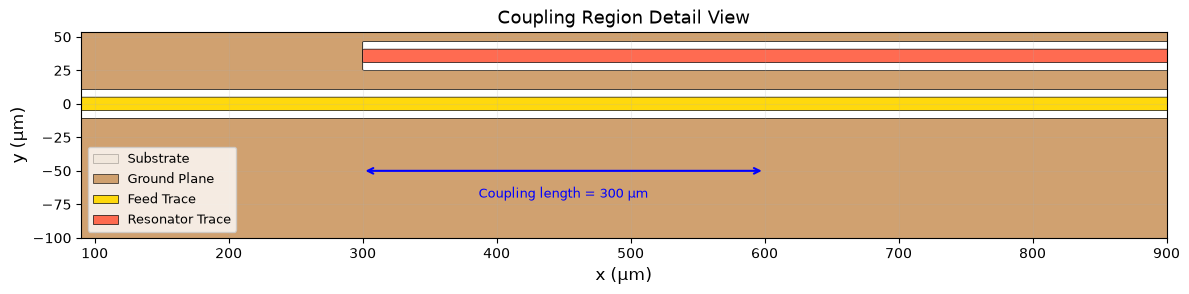

In [15]:
# ── Zoomed view of the coupling region ───────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(12, 6))

def draw_poly_ax(ax, poly, color, label=None, alpha=1.0, edgecolor='black', lw=0.5):
    if poly is None or poly.is_empty:
        return
    geoms = poly.geoms if isinstance(poly, MultiPolygon) else [poly]
    first = True
    for g in geoms:
        xs = [x * 1e6 for x in g.exterior.xy[0]]  # convert to μm for detail view
        ys = [y * 1e6 for y in g.exterior.xy[1]]
        ax.fill(xs, ys, color=color, alpha=alpha,
                label=label if first else None,
                edgecolor=edgecolor, linewidth=lw)
        for hole in g.interiors:
            hx = [x * 1e6 for x in hole.xy[0]]
            hy = [y * 1e6 for y in hole.xy[1]]
            ax.fill(hx, hy, color='white', edgecolor=edgecolor, linewidth=lw)
        first = False

draw_poly_ax(ax2, layout.substrate_footprint, '#E8E0D0', 'Substrate', alpha=0.3)
draw_poly_ax(ax2, layout.ground_plane, '#C9935A', 'Ground Plane', alpha=0.85)
draw_poly_ax(ax2, layout.feed_trace, '#FFD700', 'Feed Trace', alpha=0.95)
draw_poly_ax(ax2, layout.resonator_trace, '#FF6347', 'Resonator Trace', alpha=0.95)

# Zoom into coupling region
margin = params.substrate_margin_x_m * 1e6
coupling_end = (margin + COUPLING_LEN * 1e6) * 1.5
ax2.set_xlim(margin * 0.3, coupling_end)
y_center = (params.feed_width_m/2 + cross_section.gap_m + COUPLING_GAP + CENTER_WIDTH_M/2) * 1e6 / 2
ax2.set_ylim(-100, y_center * 3)

# Annotate dimensions
ax2.annotate('', xy=(margin, -50), xytext=(margin + COUPLING_LEN*1e6, -50),
             arrowprops=dict(arrowstyle='<->', color='blue', lw=1.5))
ax2.text(margin + COUPLING_LEN*1e6/2, -70,
         f'Coupling length = {COUPLING_LEN*1e6:.0f} μm',
         ha='center', fontsize=9, color='blue')

ax2.set_aspect('equal')
ax2.set_xlabel('x (μm)', fontsize=12)
ax2.set_ylabel('y (μm)', fontsize=12)
ax2.set_title('Coupling Region Detail View', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2)
fig2.tight_layout()
plt.show()

In [17]:
# ── Build 3D model from 2D layout ────────────────────────────────────────
model3d = build_3d_model(layout)

display(Markdown("### 3D Model Components"))
parts = {
    'Substrate': model3d.substrate,
    'Ground Plane': model3d.ground_plane,
    'Feed Trace': model3d.feed_trace,
    'Resonator Trace': model3d.resonator_trace,
    'Air Box': model3d.air_box,
}

for name, shape in parts.items():
    if shape is None:
        print(f"  {name:<20}: Not generated")
    else:
        val = shape.val() if hasattr(shape, 'val') else shape
        shape_type = val.ShapeType() if hasattr(val, 'ShapeType') else type(val).__name__
        print(f"  {name:<20}: {shape_type}")

print(f"\n  Metal thickness: {'Zero (2D PEC sheet)' if METAL_THICKNESS == 0 else f'{METAL_THICKNESS*1e9:.0f} nm'}")
print(f"  Substrate thickness: {SUBSTRATE.thickness_m*1e6:.0f} μm")


Polygon diagnostics
-------------------------
Ground vertices    : 5
Feed vertices      : 69
Resonator vertices : 481
Ground valid : True
Feed valid   : True
Res valid    : True
Ground solid: Solid
Feed solid: Solid
Resonator solid: Solid


### 3D Model Components

  Substrate           : Solid
  Ground Plane        : Solid
  Feed Trace          : Solid
  Resonator Trace     : Solid
  Air Box             : Solid

  Metal thickness: Zero (2D PEC sheet)
  Substrate thickness: 500 μm


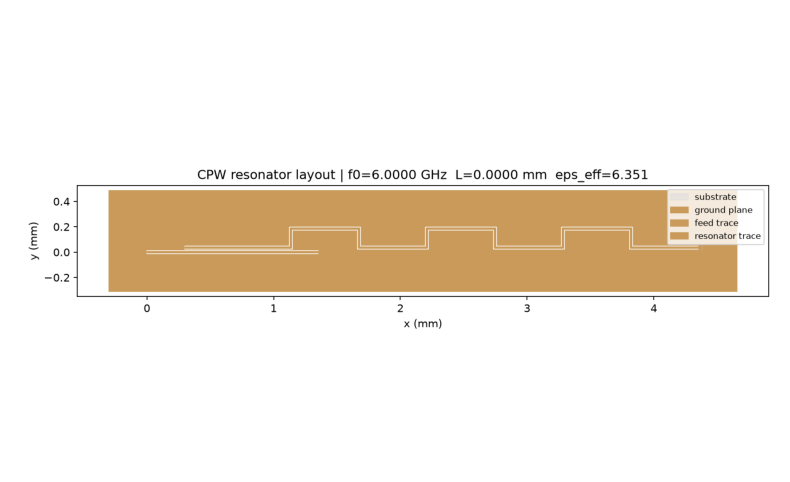

In [18]:
# ── Interactive 3D viewer ────────────────────────────────────────────────
from src.viewer import view_model_3d, quick_layout_preview

# Quick 2D preview (no cadquery dependency needed)
quick_layout_preview(layout)

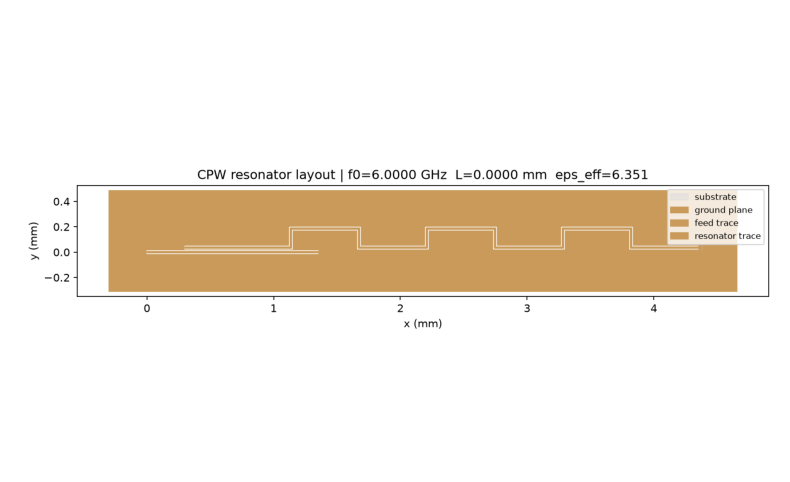

In [19]:
# ── Interactive 3D viewer ────────────────────────────────────────────────
from src.viewer import view_model_3d, quick_layout_preview

# Quick 2D preview (no cadquery dependency needed)
quick_layout_preview(layout)

In [21]:
# ── Full 3D interactive view ─────────────────────────────────────────────
# Custom color scheme for the 3D model
custom_colors = {
    "substrate":      "#6A8EAE",   # steel blue for silicon
    "ground_plane":   "#C9935A",   # copper/gold for metal
    "feed_trace":     "#DAA520",   # goldenrod
    "resonator_trace": "#FF6347",  # tomato red for resonator
}

plotter = view_model_3d(
    model3d,
    colors=custom_colors,
    notebook=False,  # Updated for better VS Code compatibility
)

📸 Screenshot saved to: /mnt/d/VIT/SEM 5/RIT HACKATHON - CPW/CPWpython/notebooks/cpw_3d_model.png


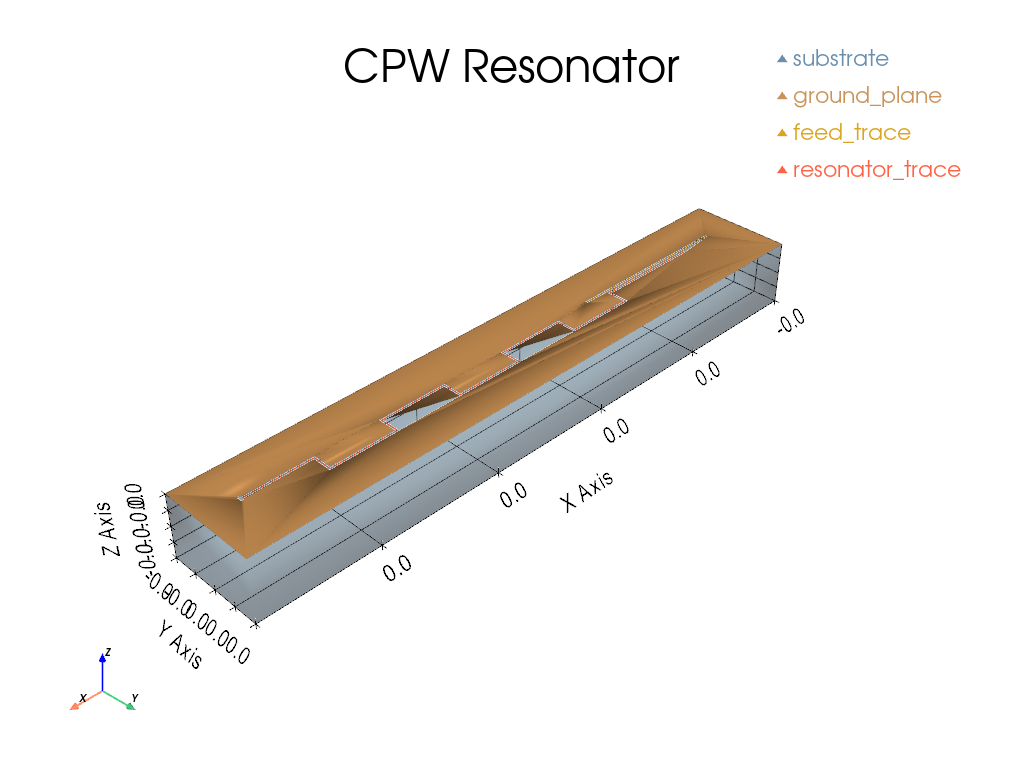

In [22]:
# ── Save a static screenshot of the 3D model ────────────────────────────
from src.viewer import save_model_image
from IPython.display import Image as IPImage

screenshot_path = str(PROJECT_ROOT / "notebooks" / "cpw_3d_model.png")
save_model_image(model3d, filename=screenshot_path, colors=custom_colors)
print(f"📸 Screenshot saved to: {screenshot_path}")

# Display the saved screenshot
IPImage(filename=screenshot_path, width=800)

In [23]:
# ── Batch export all formats ─────────────────────────────────────────────
from src.exporter import export_all, export_params_json
from pathlib import Path

EXPORT_DIR = PROJECT_ROOT / "exports" / f"cpw_{F0_GHZ}GHz_{TARGET_Z0_OHMS}ohm"

result = export_all(
    model3d=model3d,
    layout=layout,
    out_dir=EXPORT_DIR,
    prefix=f"cpw_{RESONATOR_MODE}wave",
    mode="comsol",
)

display(Markdown("### Exported Files"))
print(f"  Export directory: {EXPORT_DIR}\n")

if getattr(result, 'json_file', None):
    print(f"  📄 JSON parameters : {Path(result.json_file).name}")
if getattr(result, 'manifest_file', None):
    print(f"  📋 Manifest        : {Path(result.manifest_file).name}")
if getattr(result, 'png_file', None):
    print(f"  🖼️  PNG layout      : {Path(result.png_file).name}")

print(f"\n  STEP files ({len(result.step_files)}):")
for name, path in result.step_files.items():
    print(f"    ▸ {name:<20} → {Path(path).name}")

print(f"\n  STL files ({len(result.stl_files)}):")
for name, path in result.stl_files.items():
    print(f"    ▸ {name:<20} → {Path(path).name}")

print(f"\n  BREP files ({len(result.brep_files)}):")
for name, path in result.brep_files.items():
    print(f"    ▸ {name:<20} → {Path(path).name}")

print()
print("Export Summary")
print("-----------------------------")
print(f"STEP files : {len(result.step_files)}")
print(f"STL files  : {len(result.stl_files)}")
print(f"BREP files : {len(result.brep_files)}")

Shape 'substrate' is not a Solid. Type: CompSolid
Shape 'ground_plane' is not a Solid. Type: CompSolid
Shape 'feed_trace' is not a Solid. Type: CompSolid
Shape 'resonator_trace' is not a Solid. Type: CompSolid
/mnt/d/VIT/SEM 5/RIT HACKATHON - CPW/CPWpython/CPWPY/lib/python3.12/site-packages/cadquery/utils.py:82: FutureWarning: save will be removed in the next release.
  warn(f"{f.__name__} will be removed in the next release.", FutureWarning)



      EXPORT STATISTICS
STEP size:       4823.92 KB
BREP size:       1137.33 KB
STL size:        110.58 KB
Solid count:     4
Assembly items:  6
Bounding Box:    (x: 4.957e-03, y: 7.960e-04, z: 5.002e-04)



### Exported Files

  Export directory: /mnt/d/VIT/SEM 5/RIT HACKATHON - CPW/CPWpython/exports/cpw_6.0GHz_50.0ohm

  📄 JSON parameters : cpw_quarterwave.json
  📋 Manifest        : cpw_quarterwave_manifest.json
  🖼️  PNG layout      : cpw_quarterwave.png

  STEP files (5):
    ▸ assembly             → cpw_quarterwave.step
    ▸ substrate            → cpw_quarterwave_substrate.step
    ▸ ground_plane         → cpw_quarterwave_ground_plane.step
    ▸ feed_trace           → cpw_quarterwave_feed_trace.step
    ▸ resonator_trace      → cpw_quarterwave_resonator_trace.step

  STL files (4):
    ▸ substrate            → cpw_quarterwave_substrate.stl
    ▸ ground_plane         → cpw_quarterwave_ground_plane.stl
    ▸ feed_trace           → cpw_quarterwave_feed_trace.stl
    ▸ resonator_trace      → cpw_quarterwave_resonator_trace.stl

  BREP files (4):
    ▸ substrate            → cpw_quarterwave_substrate.brep
    ▸ ground_plane         → cpw_quarterwave_ground_plane.brep
    ▸ feed_trace           → cpw_quarterw

In [24]:
# ── One-liner end-to-end model build ─────────────────────────────────────
model_quick = build_design(
    f0_hz=5e9,                     # 5 GHz
    target_z0_ohms=50.0,           # 50 Ω
    substrate=SAPPHIRE,            # Try a different substrate
    width_m=15e-6,                 # 15 μm trace
    n_meanders=4,                  # 4 meander pairs
    meander_pitch_m=120e-6,        # 120 μm pitch
    resonator_mode="quarter",
)

print(f"✅ Quick model built:")
print(f"   Substrate: {model_quick.layout.params.substrate.name}")
print(f"   Resonator length: {model_quick.layout.metadata.resonator_length_actual_m*1e3:.3f} mm")
print(f"   Z₀: {model_quick.layout.design.z0_ohms:.2f} Ω")
print(f"   εₑff: {model_quick.layout.design.eps_eff:.4f}")


Polygon diagnostics
-------------------------
Ground vertices    : 5
Feed vertices      : 69
Resonator vertices : 617
Ground valid : True
Feed valid   : True
Res valid    : True
Ground solid: Solid
Feed solid: Solid
Resonator solid: Solid
✅ Quick model built:
   Substrate: Sapphire
   Resonator length: 6.391 mm
   Z₀: 50.00 Ω
   εₑff: 5.5018


In [26]:
# ── Multi-frequency design table ─────────────────────────────────────────
frequencies_ghz = [4.0, 5.0, 6.0, 7.0, 8.0]

display(Markdown("### Multi-Frequency Design Comparison"))
display(Markdown(f"*Substrate: {SUBSTRATE.name} | w = {CENTER_WIDTH_UM} μm | Z₀ = {TARGET_Z0_OHMS} Ω*"))
print()
print(f"{'f₀ (GHz)':>10} {'s (μm)':>10} {'εₑff':>10} {'λ_g (mm)':>12} {'L_λ/4 (mm)':>12} {'L_λ/2 (mm)':>12} {'v_ph (×10⁶ m/s)':>18}")
print("─" * 90)

for f_ghz in frequencies_ghz:
    f_hz = f_ghz * 1e9
    d = design_cpw(f_hz, TARGET_Z0_OHMS, SUBSTRATE, width_m=CENTER_WIDTH_M, mode='quarter')
    vp = phase_velocity(d.eps_eff)
    lg = guided_wavelength(f_hz, d.eps_eff)
    l_qw = quarter_wave_length(f_hz, d.eps_eff)
    l_hw = half_wave_length(f_hz, d.eps_eff)
    print(f"{f_ghz:>10.1f} {d.gap_m*1e6:>10.3f} {d.eps_eff:>10.4f} {lg*1e3:>12.4f} {l_qw*1e3:>12.4f} {l_hw*1e3:>12.4f} {vp/1e6:>18.2f}")

### Multi-Frequency Design Comparison

*Substrate: Silicon | w = 10.0 μm | Z₀ = 50.0 Ω*


  f₀ (GHz)     s (μm)       εₑff     λ_g (mm)   L_λ/4 (mm)   L_λ/2 (mm)    v_ph (×10⁶ m/s)
──────────────────────────────────────────────────────────────────────────────────────────
       4.0      5.825     6.3509      29.7402       7.4351      14.8701             118.96
       5.0      5.825     6.3509      23.7922       5.9480      11.8961             118.96
       6.0      5.825     6.3509      19.8268       4.9567       9.9134             118.96
       7.0      5.825     6.3509      16.9944       4.2486       8.4972             118.96
       8.0      5.825     6.3509      14.8701       3.7175       7.4351             118.96


In [27]:
# ── Final design summary ─────────────────────────────────────────────────
metal_text = (
    "PEC surface (0 nm)"
    if METAL_THICKNESS == 0
    else f"{METAL_THICKNESS*1e9:.0f} nm"
)

display(Markdown("---"))
display(Markdown("## 📊 Final Design Summary"))
display(Markdown(f"""
| Parameter | Value |
|---|---|
| **Resonant frequency** | {F0_GHZ} GHz |
| **Characteristic impedance** | {design.z0_ohms:.4f} Ω |
| **Effective permittivity** | {design.eps_eff:.6f} |
| **Resonator mode** | {RESONATOR_MODE}-wave (λ/{4 if RESONATOR_MODE=='quarter' else 2}) |
| **Center conductor width (w)** | {design.width_m*1e6:.3f} μm |
| **Gap width (s)** | {design.gap_m*1e6:.3f} μm |
| **Resonator length (electrical)** | {design.resonator_length_m*1e3:.4f} mm |
| **Resonator length (routed)** | {layout.metadata.resonator_length_actual_m*1e3:.4f} mm |
| **Phase velocity** | {phase_velocity(design.eps_eff)/1e6:.2f} × 10⁶ m/s |
| **Guided wavelength** | {guided_wavelength(F0_HZ, design.eps_eff)*1e3:.4f} mm |
| | |
| **Substrate** | {SUBSTRATE.name} (εᵣ = {SUBSTRATE.eps_r}, h = {SUBSTRATE.thickness_m*1e6:.0f} μm) |
| **Conductor** | {CONDUCTOR.name} |
| **Metal thickness** | {metal_text} |
| | |
| **Meander turns** | {N_MEANDERS} |
| **Meander pitch** | {MEANDER_PITCH*1e6:.0f} μm |
| **Coupling length** | {COUPLING_LEN*1e6:.0f} μm |
| **Coupling gap** | {COUPLING_GAP*1e6:.0f} μm |
| | |
| **Chip size** | {(m.bounding_box[2]-m.bounding_box[0])*1e3:.3f} × {(m.bounding_box[3]-m.bounding_box[1])*1e3:.3f} mm² |
| **Metal area** | {m.metal_area_sq_m*1e6:.4f} mm² |
| **Ground area** | {m.ground_area_sq_m*1e6:.4f} mm² |
"""))

print("\n🎉 CPW Resonator model complete!")
print(f"   Exported files → {EXPORT_DIR}")

---

## 📊 Final Design Summary


| Parameter | Value |
|---|---|
| **Resonant frequency** | 6.0 GHz |
| **Characteristic impedance** | 50.0000 Ω |
| **Effective permittivity** | 6.350873 |
| **Resonator mode** | quarter-wave (λ/4) |
| **Center conductor width (w)** | 10.000 μm |
| **Gap width (s)** | 5.825 μm |
| **Resonator length (electrical)** | 4.9567 mm |
| **Resonator length (routed)** | 4.9567 mm |
| **Phase velocity** | 118.96 × 10⁶ m/s |
| **Guided wavelength** | 19.8268 mm |
| | |
| **Substrate** | Silicon (εᵣ = 11.7, h = 500 μm) |
| **Conductor** | Niobium (lossless, PEC approx.) |
| **Metal thickness** | PEC surface (0 nm) |
| | |
| **Meander turns** | 3 |
| **Meander pitch** | 150 μm |
| **Coupling length** | 300 μm |
| **Coupling gap** | 20 μm |
| | |
| **Chip size** | 4.957 × 0.796 mm² |
| **Metal area** | 0.0640 mm² |
| **Ground area** | 3.8072 mm² |



🎉 CPW Resonator model complete!
   Exported files → /mnt/d/VIT/SEM 5/RIT HACKATHON - CPW/CPWpython/exports/cpw_6.0GHz_50.0ohm


In [28]:
# ── View Generated Project Tree ──────────────────────────────────────────
from pathlib import Path

print("\nGenerated Project Tree")
print("------------------------")
for p in sorted(EXPORT_DIR.rglob("*")):
    if p.is_file():
        print(p.relative_to(EXPORT_DIR))


Generated Project Tree
------------------------
cpw_quarterwave.json
cpw_quarterwave.png
cpw_quarterwave.step
cpw_quarterwave_feed_trace.brep
cpw_quarterwave_feed_trace.step
cpw_quarterwave_feed_trace.stl
cpw_quarterwave_ground_plane.brep
cpw_quarterwave_ground_plane.step
cpw_quarterwave_ground_plane.stl
cpw_quarterwave_manifest.json
cpw_quarterwave_resonator_trace.brep
cpw_quarterwave_resonator_trace.step
cpw_quarterwave_resonator_trace.stl
cpw_quarterwave_substrate.brep
cpw_quarterwave_substrate.step
cpw_quarterwave_substrate.stl
